In [5]:
import pandas as pd
import glob

files = glob.glob("snapshots/*.parquet")
df_pred = pd.concat([pd.read_parquet(f) for f in files])
#df = df.sort_values(by="forecast_time")

df_actual = pd.read_csv("london_actual_weather.csv")
df_actual['observation_time']=df_actual['observation_time'].astype("datetime64[us]")

df_tot = df_pred.merge(df_actual, left_on='forecast_time', right_on='observation_time')

df_tot.head(20)

,scrape_time,forecast_time,temp,temp_perc,rain_prob,condition,wind_speed,wind_direction,humidity,pressure,horizon_hours,observation_time,actual_temp,actual_humidity,actual_precipitation,actual_pressure,actual_wind_speed,actual_wind_direction
0,2026-05-22 11:42:06.033768,2026-05-22 13:00:00,25,28,0,Sunny,16,S,50,1025,1.298324,2026-05-22 13:00:00,27.0,39,0.0,1022.5,13.9,178
1,2026-05-16 05:50:28.357187,2026-05-22 13:00:00,25,27,0,Sunny,12,SSE,47,1023,151.158790,2026-05-22 13:00:00,27.0,39,0.0,1022.5,13.9,178
2,2026-05-20 14:52:56.587634,2026-05-22 13:00:00,25,28,0,Sunny,16,S,50,1026,46.117615,2026-05-22 13:00:00,27.0,39,0.0,1022.5,13.9,178
3,2026-05-11 19:41:47.228606,2026-05-22 13:00:00,21,22,51,Light Rain Showers,10,SSE,55,1021,257.303548,2026-05-22 13:00:00,27.0,39,0.0,1022.5,13.9,178
4,2026-05-10 10:09:54.206650,2026-05-22 13:00:00,19,19,54,Drizzle,13,SW,52,1013,290.834943,2026-05-22 13:00:00,27.0,39,0.0,1022.5,13.9,178
5,2026-05-19 02:46:51.794328,2026-05-22 13:00:00,25,28,0,Sunny,12,S,49,1024,82.218946,2026-05-22 13:00:00,27.0,39,0.0,1022.5,13.9,178
6,2026-05-20 06:44:50.096482,2026-05-22 13:00:00,25,28,0,Sunny,16,S,50,1025,54.252751,2026-05-22 13:00:00,27.0,39,0.0,1022.5,13.9,178
7,2026-05-17 21:50:57.715670,2026-05-22 13:00:00,24,26,0,Sunny Intervals,11,S,49,1023,111.150635,2026-05-22 13:00:00,27.0,39,0.0,1022.5,13.9,178
8,2026-05-10 21:42:47.118670,2026-05-22 13:00:00,20,20,52,Light Rain Showers,10,WSW,50,1025,279.286911,2026-05-22 13:00:00,27.0,39,0.0,1022.5,13.9,178
9,2026-05-13 06:24:01.000528,2026-05-22 13:00:00,22,23,16,Sunny Intervals,10,S,46,1026,222.599722,2026-05-22 13:00:00,27.0,39,0.0,1022.5,13.9,178


In [22]:
#df_tot.hist(column="horizon_hours")
df_tot[.0 < df_tot['horizon_hours']].count()

scrape_time              93892
forecast_time            93892
temp                     93892
temp_perc                93892
rain_prob                93892
condition                93892
wind_speed               93892
wind_direction           93892
humidity                 93892
pressure                 93892
horizon_hours            93892
observation_time         93892
actual_temp              93892
actual_humidity          93892
actual_precipitation     93892
actual_pressure          93892
actual_wind_speed        93892
actual_wind_direction    93892
dtype: int64

In [23]:
df_tot['temp']-df_tot['actual_temp']

-0.20831031983861187

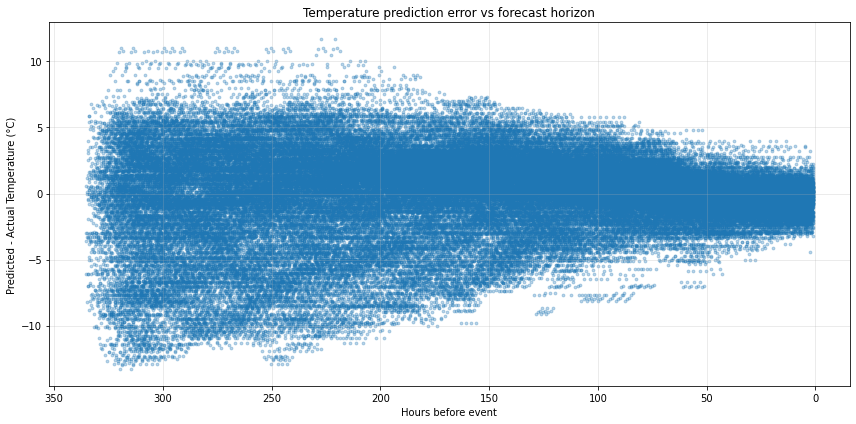

In [25]:
import matplotlib.pyplot as plt

df_tot["temp_diff"] = df_tot["temp"] - df_tot["actual_temp"]

plt.figure(figsize=(12, 6))

plt.scatter(
    df_tot["horizon_hours"],
    df_tot["temp_diff"],
    s=8,
    alpha=0.3
)

plt.xlabel("Hours before event")
plt.ylabel("Predicted - Actual Temperature (°C)")
plt.title("Temperature prediction error vs forecast horizon")

# Reverse x-axis so the event is on the right
plt.gca().invert_xaxis()

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

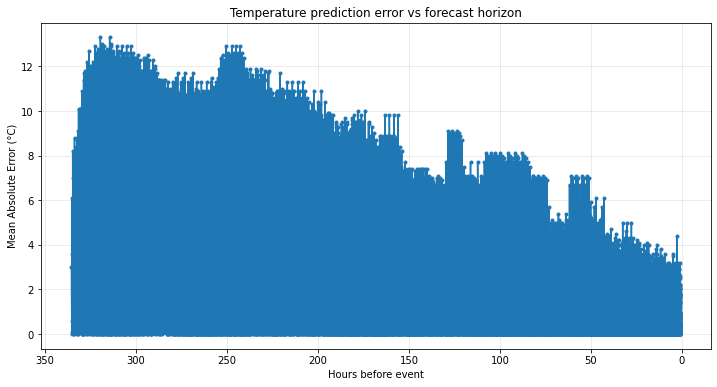

In [27]:
import matplotlib.pyplot as plt

df_tot["temp_error"] = (df_tot["temp"] - df_tot["actual_temp"]).abs()

summary = (
    df_tot.groupby("horizon_hours")
      .agg(
          mean_error=("temp_error", "mean"),
          median_error=("temp_error", "median"),
          std_error=("temp_error", "std"),
          n=("temp_error", "size")
      )
      .reset_index()
      .sort_values("horizon_hours", ascending=False)
)

plt.figure(figsize=(12,6))

plt.plot(
    summary["horizon_hours"],
    summary["mean_error"],
    marker="o",
    markersize=3
)

plt.xlabel("Hours before event")
plt.ylabel("Mean Absolute Error (°C)")
plt.title("Temperature prediction error vs forecast horizon")

plt.gca().invert_xaxis()
plt.grid(alpha=0.3)

plt.show()

In [31]:
import numpy as np

bins = [
      0, 1, 2, 3, 4, 5, 6, 9, 12,
     18,  24,
     36,  48,
     72,
     96,
    120,
    168,
    240
]

labels = [
    "0-1",
    "1-2",
    "2-3",
    "3-4",
    "4-5",
    "5-6",
    "6-9",
    "9-12",
    "12-18",
    "18-24",
    "24-36",
    "36-48",
    "48-72",
    "72-96",
    "96-120",
    "120-168",
    "168-240"
]

df_tot["horizon_bin"] = pd.cut(
    df_tot["horizon_hours"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

summary = (
    df_tot.assign(temp_error=(df_tot["temp"] - df_tot["actual_temp"]).abs())
      .groupby("horizon_bin", observed=True)
      .agg(
          mean_error=("temp_error", "mean"),
          median_error=("temp_error", "median"),
          std_error=("temp_error", "std"),
          n=("temp_error", "size")
      )
      .reset_index()
)

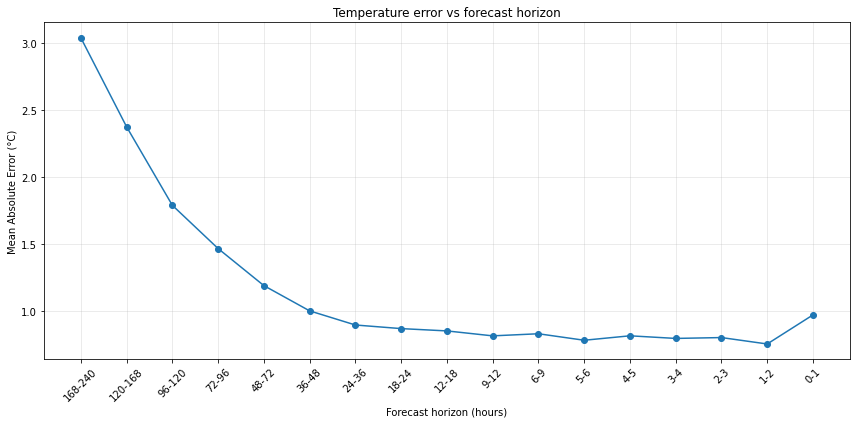

In [33]:
# make this filterable by different temperatures

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(summary["horizon_bin"].astype(str),
         summary["mean_error"],
         marker="o")

plt.xticks(rotation=45)
plt.xlabel("Forecast horizon (hours)")
plt.ylabel("Mean Absolute Error (°C)")
plt.title("Temperature error vs forecast horizon")

plt.gca().invert_xaxis()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17]),
 [Text(1, 0, '0-1'),
  Text(2, 0, '1-2'),
  Text(3, 0, '2-3'),
  Text(4, 0, '3-4'),
  Text(5, 0, '4-5'),
  Text(6, 0, '5-6'),
  Text(7, 0, '6-9'),
  Text(8, 0, '9-12'),
  Text(9, 0, '12-18'),
  Text(10, 0, '18-24'),
  Text(11, 0, '24-36'),
  Text(12, 0, '36-48'),
  Text(13, 0, '48-72'),
  Text(14, 0, '72-96'),
  Text(15, 0, '96-120'),
  Text(16, 0, '120-168'),
  Text(17, 0, '168-240')])

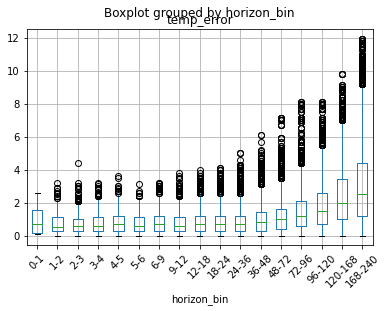

In [35]:
df_tot.boxplot(column="temp_error", by="horizon_bin")
plt.xticks(rotation=45)

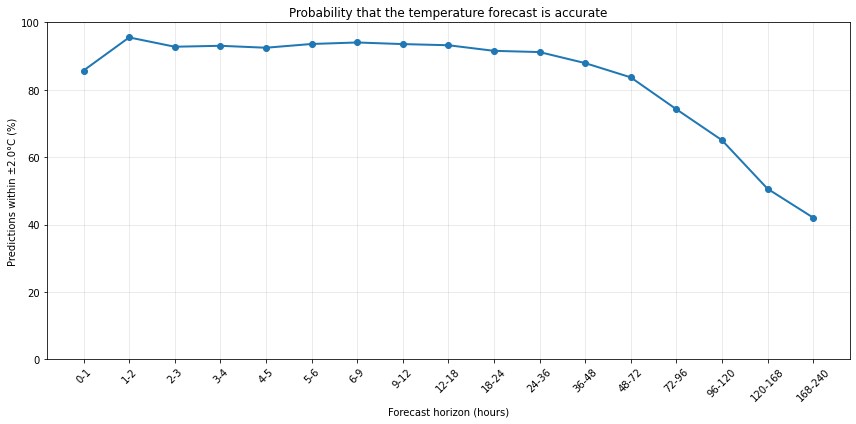

In [40]:
import matplotlib.pyplot as plt

# Absolute error
df_tot["temp_error"] = (df_tot["temp"] - df_tot["actual_temp"]).abs()

# Define what "accurate" means
THRESHOLD = 2.0  # °C

df_tot["accurate"] = df_tot["temp_error"] <= THRESHOLD

# Compute probability of being accurate for each horizon bin
summary = (
    df_tot.groupby("horizon_bin", observed=True)
      .agg(
          probability=("accurate", "mean"),
          n=("accurate", "size")
      )
      .reset_index()
)

# Convert to percentage
summary["probability"] *= 100

# Plot
plt.figure(figsize=(12, 6))

plt.plot(
    summary["horizon_bin"].astype(str),
    summary["probability"],
    marker="o",
    linewidth=2
)

plt.xlabel("Forecast horizon (hours)")
plt.ylabel(f"Predictions within ±{THRESHOLD}°C (%)")
plt.title("Probability that the temperature forecast is accurate")

plt.ylim(0, 100)
plt.grid(alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [42]:
# research into rain
# what is the relationtship between rain probability and rain condition
# realtionship between rain probability and rain happening

summary = (
    df_tot.groupby("condition")
      .agg(
          mean_prob=("rain_prob", "mean"),
          median_prob=("rain_prob", "median"),
          p25=("rain_prob", lambda x: x.quantile(0.25)),
          p75=("rain_prob", lambda x: x.quantile(0.75)),
          n=("rain_prob", "size")
      )
      .sort_values("median_prob")
)
summary

,mean_prob,median_prob,p25,p75,n
condition,,,,,
Clear Sky,6.336549,0,0,14,12334
Mist,0.000000,0,0,0,6
Sunny,6.616560,0,0,14,19372
Partly Cloudy,11.837912,11,0,21,8335
Sunny Intervals,11.659370,11,0,21,16126
Light Cloud,12.262502,13,0,22,11398
Thick Cloud,15.384734,17,6,24,1297
Drizzle,44.230678,43,36,51,9251
Light Rain Showers,52.126912,48,38,63,17327


<Figure size 1008x432 with 0 Axes>

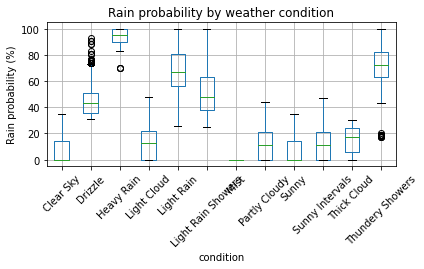

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

df_tot.boxplot(
    column="rain_prob",
    by="condition",
    rot=45
)

plt.ylabel("Rain probability (%)")
plt.title("Rain probability by weather condition")
plt.suptitle("")
plt.tight_layout()
plt.show()

In [1]:
import os
import requests

icons = {
    "clear_sky": 0,
    "sunny": 1,
    "partly_cloudy": 2,
    "sunny_intervals": 3,
    "mist": 5,
    "light_cloud": 7,
    "thick_cloud": 8,
    "light_rain_showers": 10,
    "drizzle": 11,
    "light_rain": 12,
    "heavy_rain": 15,
    "thundery_showers": 29,
}

output_dir = "weather_icons"
os.makedirs(output_dir, exist_ok=True)

base_url = "https://www.bbc.co.uk/weather/images/symbols/57x57"

for name, code in icons.items():
    url = f"{base_url}/{code}.gif"
    output_file = os.path.join(output_dir, f"{name}.gif")

    print(f"Downloading {name} ({code})...")

    response = requests.get(url, timeout=10)

    if response.status_code == 200:
        with open(output_file, "wb") as f:
            f.write(response.content)

        print(f"  ✓ {output_file}")
    else:
        print(f"  ✗ HTTP {response.status_code}: {url}")

  ✗ HTTP 404: https://www.bbc.co.uk/weather/images/symbols/57x57/0.gif
  ✗ HTTP 404: https://www.bbc.co.uk/weather/images/symbols/57x57/1.gif
  ✗ HTTP 404: https://www.bbc.co.uk/weather/images/symbols/57x57/2.gif
  ✗ HTTP 404: https://www.bbc.co.uk/weather/images/symbols/57x57/3.gif
  ✗ HTTP 404: https://www.bbc.co.uk/weather/images/symbols/57x57/5.gif
  ✗ HTTP 404: https://www.bbc.co.uk/weather/images/symbols/57x57/7.gif
  ✗ HTTP 404: https://www.bbc.co.uk/weather/images/symbols/57x57/8.gif
  ✗ HTTP 404: https://www.bbc.co.uk/weather/images/symbols/57x57/10.gif
  ✗ HTTP 404: https://www.bbc.co.uk/weather/images/symbols/57x57/11.gif
  ✗ HTTP 404: https://www.bbc.co.uk/weather/images/symbols/57x57/12.gif
  ✗ HTTP 404: https://www.bbc.co.uk/weather/images/symbols/57x57/15.gif
  ✗ HTTP 404: https://www.bbc.co.uk/weather/images/symbols/57x57/29.gif


In [ ]:
# todos:
# - Add interaction at the beginning: user puts % rain probability and i show the different possible icons
# - after the distribution of rain probability vs condition, add a timeline as this might vary
# - are there factors that contribute to a wwrong prediction? Like, time of the day, day of the week?
# - (maybe) add an example of two bad scenarios, timelapse of prediction changing
# - Is the forecast error significantly different between forecast horizons?